In [27]:
import numpy as np
import os
from pathlib import Path
import pandas as pd
from scclone2dr.pipeline import scClone2DRPipeline
import scclone2dr

COHORT = 'aml'
gene_set_collections = ['geneOncoKB','gene','c6','hallmarks', 'c2_pid']
cohort2clonemodes = {'melanoma': ["scatrex",'scatrex_rawcounts_scvi', 'phenograph'], 'aml':['phenograph']}
gene_set_collection = gene_set_collections[3]
clonemode = cohort2clonemodes[COHORT][0]
mode_features = 'metacells_{0}_{1}'.format(gene_set_collection, clonemode)

if COHORT=='melanoma':
    concentration_drug = '5'
    concentration_DMSO = "100"
elif COHORT=='aml':
    concentration_drug = '10'
    concentration_DMSO = "200"

path_rna = '/data/users/04_share_reanalysis_results/aml_2025/02_atypical_removed_preprocessing/{0}/'.format(mode_features)
path_fastdrug = '/data/users/04_share_reanalysis_results/01_aml/AML_PCY_cell_numbers_no_plate_effect_correction.csv'     
path_info_cohort = '/data/users/04_share_reanalysis_results/01_aml/2024-08-15_aml_overview_scRNA.tsv'
mode_features = 'metacells_{0}_{1}'.format(gene_set_collection, clonemode)


ckpt_dir = Path("/data/users/quentin/PACKAGE/checkpoints/")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / f"{mode_features}.npz"
ckpt_path_post = ckpt_dir / f"{mode_features}_posterior_sample.npz"

datamodule = scclone2dr.data.RealData(path_fastdrug=path_fastdrug, path_rna=path_rna, path_info_cohort=path_info_cohort, concentration_drug = concentration_drug)
data_ref = datamodule.get_real_data(concentration_DMSO=concentration_DMSO, concentration_drug=concentration_drug)

# Load trained pipeline from disk.
pipeline_loaded = scClone2DRPipeline.from_file(
    ckpt_path,
    data_source=datamodule,
)
pipeline_loaded.model.configure(datamodule)

# Sample from posterior (Monte Carlo).
posterior_results = pipeline_loaded.load_posterior_samples(ckpt_path_post)

Total number of samples:  29
Number of drugs 74
Number of samples:  29
<class 'numpy.float64'>


/data/users/quentin/PACKAGE/scClone2DR/src/scclone2dr/data/realdata.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['masks']['SingleCell'] = torch.tensor(~torch.isnan(S_dense[:,:,:,0])).clone().detach()


In [28]:
pi = posterior_results['params']['PI']
props = posterior_results['params']['proportions']
D,Kmax,N = pi.shape
pi_healthy = np.zeros((D, N))
norm = np.zeros(N)

for i in datamodule.cat2clusters['healthy']:
    pi_healthy += props[:, i][None, :] * pi[:, i, :]
    norm += props[:, i]

norm = np.where(norm > 0, norm, np.nan)
pi_healthy /= norm[None, :]

pi /= pi_healthy[:, None, :]

if COHORT=="melanoma":
    model.dfinfo = None

In [29]:
df_aml = pd.read_csv('/data/users/quentin/final_package/experiments/survival_analysis/data/20240531_TPA_clinical_data_full_cohort.csv')

In [30]:
venetoclax_received_prev_lines = {}
venetoclax_received_after = {}
venetoclax_received_before = {}

for sample in datamodule.sample_names:
    if df_aml[df_aml["SampleID"]==sample]['Venetoclax in previous lines '].iloc[0]=="yes":
        venetoclax_received_prev_lines[sample] = True
    else:
        venetoclax_received_prev_lines[sample] = False
        
    if "Venetoclax" in df_aml[df_aml["SampleID"]==sample]['Treatment after TUPRO'].iloc[0]:
        venetoclax_received_after[sample] = True
    else:
        venetoclax_received_after[sample] = False
        
    if "Venetoclax" in str(df_aml[df_aml["SampleID"]==sample]['Last Treatment before TUPRO '].iloc[0]):
        venetoclax_received_before[sample] = True
    else:
        venetoclax_received_before[sample] = False

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize
from matplotlib.colors import FuncNorm

def survival_probabilities(data, piorig, cluster2clonelabel, df_info_cohort=None, idxdrug=0, label_colors=None, drug_name=None,  savefig=None):
    # Comparing true survival probabilities and the one estimated
    label2name = {'healthy':'Non-malignant', 'tumor':'Cancer', 'putative':'Putative Cancer'}

    pi = piorig.copy()
    for d in range(data['D']):
        pi[d,:,:][~(data['masks']['RNA'])] = float('nan')

    # Sort clusters based on their labels
    sorted_indices = np.argsort(cluster2clonelabel)

    sorted_indices = np.arange(len(cluster2clonelabel))  #np.argsort(cluster2clonelabel)
    sorted_pi = pi[idxdrug, sorted_indices, :]

    if not(df_info_cohort is None):
        # Sort samples by patient_id and tissue_type
        sample_names = df_info_cohort.index.values
        sorted_meta_data = df_info_cohort.sort_values(by=['patient_id', 'tissue_type'])
        sorted_sample_ids = sorted_meta_data.index
        sample2idx = {sample: idx for idx, sample in enumerate(sorted_sample_ids.values)}
        sorted_indices_patient = np.array([sample2idx[sample] for sample in sample_names])
        sorted_pi = sorted_pi[:, sorted_indices_patient]

    # Get unique cluster labels and assign a color to each
    unique_labels = np.unique(cluster2clonelabel)
    if label_colors is None:
        label_colors = plt.colormaps['tab20'](np.linspace(0, 1, len(unique_labels)))

    # Create a color array for the y-axis labels, formatted for display
    row_colors = np.array([label_colors[np.where(unique_labels == label)[0][0]] for label in np.array(cluster2clonelabel)[sorted_indices]])

    # Reshape to a 2D array of RGB colors (n_clusters, 3) -> (n_clusters, 1, 3) for displaying as an image
    row_colors = row_colors.reshape(-1, 1, 4)  # Change 3 to 4 if the color has an alpha channel (RGBA)



    if not(df_info_cohort is None):
        # Create the main plot with two subplots: one for the color bar and one for the heatmap
        fig = plt.figure(layout="constrained")
        gs = GridSpec(2, 2, figure=fig, width_ratios=[0.05, 1], height_ratios=[1, 0.05])
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
    else:
        # Create the main plot with two subplots: one for the color bar and one for the heatmap
        fig, (ax1, ax2) = plt.subplots(ncols=2, gridspec_kw={"width_ratios": [0.005, 1]}, figsize=(12, 8))

    # Plot the color bar on the left using the label colors
    ax1.imshow(row_colors, aspect='auto', interpolation='nearest')
    ax1.axis('off')  # Remove the axis for the color bar

    # Plot the heatmap using seaborn with consistent vmin and vmax across all plots
    cax = fig.add_axes([1., 0.11, 0.02, 0.81])  # [left, bottom, width, height]
    
    split = 0.5
    colors = [
    (0.0, (0, 0, 1)),     # blue
    (split, (1, 1, 1)),   # white at 1
    (1.0, (1, 0, 0))      # red
    ]    
    custom_cmap = LinearSegmentedColormap.from_list("terrain", colors)
    import copy
    cmap = copy.copy(custom_cmap)
    cmap.set_bad('lightgray')
    cmap.set_bad('lightgray')
    vmin = min([0.9, np.min(np.nan_to_num(sorted_pi))])
    vmax = max([1.1, np.max(np.nan_to_num(sorted_pi))])
    def forward(x):
        x = np.asarray(x, dtype=float)

        y = np.empty_like(x)

        # Preserve NaNs
        nan_mask = np.isnan(x)

        below = (x <= 1) & (~nan_mask)
        above = (x > 1) & (~nan_mask)

        y[nan_mask] = np.nan
        y[below] = split * (x[below] - vmin) / (1 - vmin)
        y[above] = split + (1 - split) * (x[above] - 1) / (vmax - 1)

        return y

    def inverse(y):
        y = np.asarray(y)
        x = np.empty_like(y, dtype=float)

        below = y <= split
        above = y > split

        x[below] = vmin + (y[below] / split) * (1 - vmin)
        x[above] = 1 + ((y[above] - split) / (1 - split)) * (vmax - 1)

        return x
    
    norm = FuncNorm((forward, inverse), vmin=vmin, vmax=vmax)
    
    import numpy.ma as ma

    # Create masked array directly
    data_masked = ma.masked_invalid(sorted_pi)
    sns.heatmap(data_masked, cmap=cmap, norm=norm, cbar=True, ax=ax2, yticklabels=False, linewidths=0.5, linecolor='lightgray',  cbar_ax=cax, cbar_kws={"label": "Relative cluster\nsurvival probability"})
    # Get the colorbar and increase label fontsize
    cbar = ax2.collections[0].colorbar
    cbar.set_label("Relative cluster\nsurvival probability", fontsize=14)
    ax2.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # Set the y-axis labels to the sorted cluster indices
    ax2.set_yticks(np.arange(len(sorted_indices)) + 0.5)

    # Custom legend for cluster labels
    label2clustername = {}
    for label in label2name.keys():
        if COHORT=='aml':
            label2clustername[label] = 'clusters'
        else:
            label2clustername[label] = 'clones'
    label2clustername['healthy'] = 'cells'
    handles = [mpatches.Patch(color=label_colors[i], label=f'{label2name[label]} {label2clustername[label]}') for i, label in enumerate(unique_labels)]
    if COHORT=='aml':
        ax2.legend(handles=handles, bbox_to_anchor=(0.5, 1.15), loc='upper center', fontsize=11, borderaxespad=0., ncols=2)
    else:
        ax2.legend(handles=handles, bbox_to_anchor=(0.5, 1.09), loc='upper center', borderaxespad=0., ncols=3)
    ax2.set_xticks([])

    # Optional: If you have patient labels
    # ax_heatmap.set_xticks(ticks=np.arange(sorted_pi.shape[1]))
    # ax_heatmap.set_xticklabels(patient_labels, rotation=90)
    if not(df_info_cohort is None):
        ax3 = fig.add_subplot(gs[1, 1])
        # Get unique cluster labels and assign a color to each
        unique_labels = np.unique(sorted_meta_data['patient_id'].values)
        label_colors = plt.colormaps['tab20'](np.linspace(0, 1, len(unique_labels)))
        # Create a color array for the y-axis labels, formatted for display
        col_colors = np.array([label_colors[np.where(unique_labels == label)[0][0]] for label in np.array(sorted_meta_data['patient_id'].values)])

        # Reshape to a 2D array of RGB colors (n_clusters, 3) -> (n_clusters, 1, 3) for displaying as an image
        col_colors = col_colors.reshape(1, -1, 4)  # Change 3 to 4 if the color has an alpha channel (RGBA)
        ax3.imshow(col_colors, aspect='auto', interpolation='nearest')
        #ax3.axis('off')  # Remove the axis for the color bar
        ax3.set_xlabel('Samples', fontsize=12)
        ax3.set_xticks([])
        ax3.set_yticks([])
    # Show the plot
    if not(drug_name is None):
        if drug_name == 'empty':
            pass
        else:
            plt.suptitle(f"Heatmap for the drug: {drug_name}")
            
    # Optional: Save the figure
    if savefig:
        plt.savefig(savefig, dpi=250, bbox_inches='tight')

    # Display the plot
    plt.show()



In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize
from matplotlib.colors import FuncNorm

def survival_probabilities_venetoclax_mostresistant(mask_rna, piorig, cluster2clonelabel,venetoclax_received_dic, df_info_cohort=None, idxdrug=0, label_colors=None, drug_name=None,  savefig=None):
    # Comparing true survival probabilities and the one estimated
    label2name = {'healthy':'Non-malignant', 'tumor':'Cancer', 'putative':'Putative Cancer'}

    pi = piorig.copy()
    D = pi.shape[0]
    for d in range(D):
        pi[d,:,:][~(mask_rna)] = float('nan')

    # Sort clusters based on their labels
    sorted_indices = np.argsort(cluster2clonelabel)

    sorted_indices = np.arange(len(cluster2clonelabel))  #np.argsort(cluster2clonelabel)
    sorted_pi = pi[idxdrug, sorted_indices, :]

    venetoclax_received=[]
    if not(df_info_cohort is None):
        # Sort samples by patient_id and tissue_type
        sample_names = df_info_cohort.index.values
        sorted_meta_data = df_info_cohort.sort_values(by=['patient_id', 'tissue_type'])
        sorted_sample_ids = sorted_meta_data.index
        sample2idx = {sample: idx for idx, sample in enumerate(sorted_sample_ids.values)}
        sorted_indices_patient = np.array([sample2idx[sample] for sample in sample_names])
        venetoclax_received = [venetoclax_received_dic[sample] for sample in sorted_sample_ids]
        
        sorted_pi = sorted_pi[:, sorted_indices_patient]

    # Get unique cluster labels and assign a color to each
    unique_labels = np.unique(cluster2clonelabel)
    if label_colors is None:
        label_colors = plt.colormaps['tab20'](np.linspace(0, 1, len(unique_labels)))

    # Create a color array for the y-axis labels, formatted for display
    row_colors = np.array([label_colors[np.where(unique_labels == label)[0][0]] for label in np.array(cluster2clonelabel)[sorted_indices]])

    # Reshape to a 2D array of RGB colors (n_clusters, 3) -> (n_clusters, 1, 3) for displaying as an image
    row_colors = row_colors.reshape(-1, 1, 4)  # Change 3 to 4 if the color has an alpha channel (RGBA)



    if not(df_info_cohort is None):
        # Create the main plot with two subplots: one for the color bar and one for the heatmap
        fig = plt.figure(layout="constrained")
        gs = GridSpec(3, 2, figure=fig, width_ratios=[0.05, 1], height_ratios=[1, 0.05, 0.05])
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
    else:
        # Create the main plot with two subplots: one for the color bar and one for the heatmap
        fig, (ax1, ax2) = plt.subplots(ncols=2, gridspec_kw={"width_ratios": [0.005, 1]}, figsize=(12, 8))

    # Plot the color bar on the left using the label colors
    ax1.imshow(row_colors, aspect='auto', interpolation='nearest')
    ax1.axis('off')  # Remove the axis for the color bar

    # Plot the heatmap using seaborn with consistent vmin and vmax across all plots
    cax = fig.add_axes([1., 0.11, 0.02, 0.81])  # [left, bottom, width, height]
    
    split = 0.5
    colors = [
    (0.0, (0, 0, 1)),     # blue
    (split, (1, 1, 1)),   # white at 1
    (1.0, (1, 0, 0))      # red
    ]    
    custom_cmap = LinearSegmentedColormap.from_list("terrain", colors)
    import copy
    cmap = copy.copy(custom_cmap)
    cmap.set_bad('lightgray')
    cmap.set_bad('lightgray')
    vmin = min([0.9, np.min(np.nan_to_num(sorted_pi))])
    vmax = max([1.1, np.max(np.nan_to_num(sorted_pi))])
    def forward(x):
        x = np.asarray(x, dtype=float)

        y = np.empty_like(x)

        # Preserve NaNs
        nan_mask = np.isnan(x)

        below = (x <= 1) & (~nan_mask)
        above = (x > 1) & (~nan_mask)

        y[nan_mask] = np.nan
        y[below] = split * (x[below] - vmin) / (1 - vmin)
        y[above] = split + (1 - split) * (x[above] - 1) / (vmax - 1)

        return y

    def inverse(y):
        y = np.asarray(y)
        x = np.empty_like(y, dtype=float)

        below = y <= split
        above = y > split

        x[below] = vmin + (y[below] / split) * (1 - vmin)
        x[above] = 1 + ((y[above] - split) / (1 - split)) * (vmax - 1)

        return x
    
    norm = FuncNorm((forward, inverse), vmin=vmin, vmax=vmax)
    
    import numpy.ma as ma

    # Create masked array directly
    data_masked = ma.masked_invalid(sorted_pi)
    sns.heatmap(data_masked, cmap=cmap, norm=norm, cbar=True, ax=ax2, yticklabels=False, linewidths=0.5, linecolor='lightgray',  cbar_ax=cax, cbar_kws={"label": "Relative cluster\nsurvival probability"})
    # Get the colorbar and increase label fontsize
    cbar = ax2.collections[0].colorbar
    cbar.set_label("Relative cluster\nsurvival probability", fontsize=14)
    ax2.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # Set the y-axis labels to the sorted cluster indices
    ax2.set_yticks(np.arange(len(sorted_indices)) + 0.5)
    

    # Custom legend for cluster labels
    label2clustername = {}
    for label in label2name.keys():
        if COHORT=='aml':
            label2clustername[label] = 'clusters'
        else:
            label2clustername[label] = 'clones'
    label2clustername['healthy'] = 'cells'
    handles = [mpatches.Patch(color=label_colors[i], label=f'{label2name[label]} {label2clustername[label]}') for i, label in enumerate(unique_labels)]
    # Add dot legend entry
    from matplotlib.lines import Line2D

    handles.append(
        Line2D([0], [0],
               marker='o',
               color='w',
               markerfacecolor='black',
               markersize=6,
               label='Received the drug')
    )
    if COHORT=='aml':
        ax2.legend(handles=handles, bbox_to_anchor=(0.5, 1.15), loc='upper center', fontsize=11, borderaxespad=0., ncols=2)
    else:
        ax2.legend(handles=handles, bbox_to_anchor=(0.5, 1.09), loc='upper center', borderaxespad=0., ncols=3)
    
    ax2.set_xticks([])

    # Optional: If you have patient labels
    # ax_heatmap.set_xticks(ticks=np.arange(sorted_pi.shape[1]))
    # ax_heatmap.set_xticklabels(patient_labels, rotation=90)
    if not(df_info_cohort is None):
        ax3 = fig.add_subplot(gs[2, 1])
        # Get unique cluster labels and assign a color to each
        unique_labels = np.unique(sorted_meta_data['patient_id'].values)
        label_colors = plt.colormaps['tab20'](np.linspace(0, 1, len(unique_labels)))
        # Create a color array for the y-axis labels, formatted for display
        col_colors = np.array([label_colors[np.where(unique_labels == label)[0][0]] for label in np.array(sorted_meta_data['patient_id'].values)])

        # Reshape to a 2D array of RGB colors (n_clusters, 3) -> (n_clusters, 1, 3) for displaying as an image
        col_colors = col_colors.reshape(1, -1, 4)  # Change 3 to 4 if the color has an alpha channel (RGBA)
        ax3.imshow(col_colors, aspect='auto', interpolation='nearest')
        #ax3.axis('off')  # Remove the axis for the color bar
        ax3.set_xlabel('Samples', fontsize=12)
        ax3.set_xticks([])
        ax3.set_yticks([])
        
        
        # Add dots for Venetoclax
        ven = venetoclax_received
        x_positions = np.where(ven)[0]

        ax3.scatter(
            x_positions,
            np.zeros_like(x_positions),
            color='black',
            s=15,
            zorder=3
        )
        
        ax4 = fig.add_subplot(gs[1, 1])
        idxstumor = np.where(np.array(cluster2clonelabel)!="healthy")[0]
        # Identify columns that were entirely NaN
        pitumor = np.max(np.nan_to_num(sorted_pi[idxstumor, :]), axis=0)

        nan_cols = np.isnan(sorted_pi[idxstumor, :]).all(axis=0)

        # Map values to colors using the same cmap/norm as the heatmap
        pitumor_colors = cmap(norm(pitumor))

        # Set color to gray where all values were NaN
        pitumor_colors[nan_cols] = [0.5, 0.5, 0.5, 1.0]
        pitumor_colors = pitumor_colors.reshape(1, -1, 4)
        ax4.imshow(pitumor_colors, aspect='auto', interpolation='nearest')
        
        ax4.set_xlabel('Most resistant (putative) cancer cluster', fontsize=12)
        ax4.set_xticks([])
        ax4.set_yticks([])
        
        # Fisher test
        from scipy.stats import fisher_exact
        idxs_valid_samples = np.where(~nan_cols)[0]
        table = np.zeros((2,2))
        for i, idx_samp in enumerate(idxs_valid_samples):
            if pitumor[idx_samp]<1:
                if venetoclax_received[i]:
                    table[0,0] += 1
                else:
                    table[0,1] += 1
            else:
                if venetoclax_received[i]:
                    table[1,0] += 1
                else:
                    table[1,1] += 1
        
        res = fisher_exact(table, alternative='two-sided')
        print("p value Fisher exact test: ", res)
        
        
                         
                         
    # Show the plot
    if not(drug_name is None):
        if drug_name == 'empty':
            pass
        else:
            plt.suptitle(f"Heatmap for the drug: {drug_name}")
            
    # Optional: Save the figure
    if savefig:
        plt.savefig(savefig, dpi=250, bbox_inches='tight')

    # Display the plot
    plt.show()

70
p value Fisher exact test:  SignificanceResult(statistic=np.float64(3.5), pvalue=np.float64(0.3747886895712982))


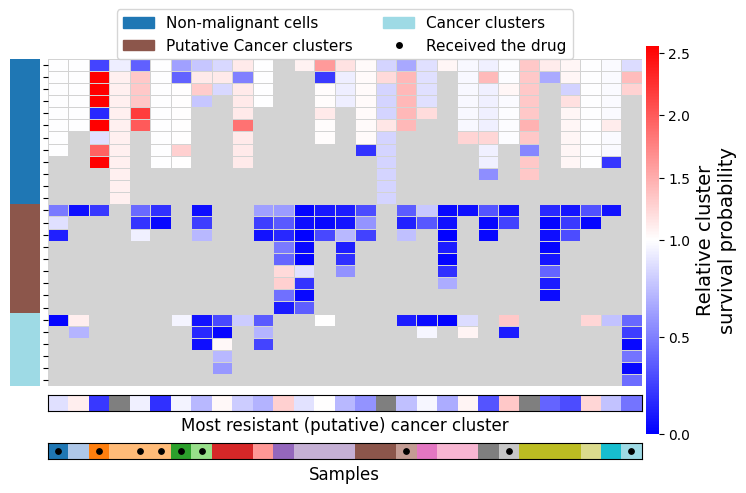

In [34]:
import copy
mask_rna = data_ref['masks']['RNA']
for idxdrug, drug_name in enumerate(datamodule.drugs):
    if drug_name=="Venetoclax":
        print(idxdrug)
        global_min = 1
        global_max = 1
        global_min = np.min([global_min, np.nanmin(pi[idxdrug,:,:])])
        global_max = np.max([global_max, np.nanmax(pi[idxdrug,:,:])])
        survival_probabilities_venetoclax_mostresistant(mask_rna, copy.deepcopy(pi), datamodule.cluster2clonelabel,venetoclax_received_after, df_info_cohort=datamodule.dfinfo, idxdrug=idxdrug, drug_name=None)